In [1]:
# !pip install -q uv
# !uv pip install --system tensorflow-data-validation

In [2]:
#
import pandas as pd
import numpy as np
# import tensorflow_data_validation as tfdv

In [3]:
df_acc = pd.read_csv('moneycraft_accounts.csv')
df_acc['month'] = pd.PeriodIndex(df_acc['month'], freq='M')
df_acc.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
1,2,2022-01,Online,London,55-64,Silver,11,False
2,3,2022-01,Branch,South East,25-34,Platinum,28,False
3,4,2022-01,Referral,London,25-34,Silver,0,True
4,5,2022-01,Comparison Site,South East,35-44,Silver,11,False


In [4]:
df_mark = pd.read_csv('moneycraft_marketing_spend.csv')
df_mark['month'] = pd.PeriodIndex(df_mark['month'], freq='M')
df_mark.head()

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0


In [5]:
switches = (df_acc.sort_values(['customer_id', 'month'])
                  .groupby('customer_id')['account_tier']
                  .apply(lambda s: (s != s.shift()).sum() - 1))

switches.head(20)

customer_id
1     0
2     2
3     2
4     0
5     1
6     2
7     0
8     1
9     2
10    1
11    0
12    0
13    0
14    3
15    0
16    0
17    0
18    1
19    2
20    3
Name: account_tier, dtype: int64

In [6]:
df_acc['customer_id'].nunique()
#15732

15732

In [7]:
df_acc.dtypes

customer_id                int64
month                  period[M]
acquisition_channel       object
region                    object
age_band                  object
account_tier              object
monthly_fee                int64
joined_on_promo             bool
dtype: object

In [8]:
df_acc = df_acc.sort_values(['customer_id', 'month'])
df_acc

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
280,1,2022-02,Comparison Site,Scotland,25-34,Classic,0,False
840,1,2022-03,Comparison Site,Scotland,25-34,Classic,0,False
1664,1,2022-04,Comparison Site,Scotland,25-34,Classic,0,False
2750,1,2022-05,Comparison Site,Scotland,25-34,Classic,0,False
...,...,...,...,...,...,...,...,...
179013,15728,2024-12,Outbound,Midlands,35-44,Silver,0,True
179014,15729,2024-12,Comparison Site,Midlands,25-34,Classic,0,True
179015,15730,2024-12,Referral,London,25-34,Gold,18,False
179016,15731,2024-12,Online,South East,55-64,Platinum,28,False


In [9]:
grouped = df_acc.groupby('customer_id')

# A few simple summaries, one per customer:
signup_month  = grouped['month'].min()    # their FIRST month
last_active   = grouped['month'].max()    # their LAST month
tenure_months = grouped['month'].count()  # how many months in total

signup_month.head()

customer_id
1    2022-01
2    2022-01
3    2022-01
4    2022-01
5    2022-01
Name: month, dtype: period[M]

In [10]:
grouped['joined_on_promo'].first()

customer_id
1        False
2        False
3        False
4         True
5        False
         ...  
15728     True
15729     True
15730    False
15731    False
15732     True
Name: joined_on_promo, Length: 15732, dtype: bool

In [11]:
channel    = grouped['acquisition_channel'].first() # Assuming they haven't rejoined using a different channel
region     = grouped['region'].first() # Assuming they haven't moved
age_band   = grouped['age_band'].first() # Assuming they haven't aged
first_plan = grouped['account_tier'].first()   # the plan they STARTED on
last_plan  = grouped['account_tier'].last()    # the plan they ENDED on
promo_join = grouped['joined_on_promo'].first() # whether they joined on promo


first_plan.head()

customer_id
1     Classic
2      Silver
3    Platinum
4      Silver
5      Silver
Name: account_tier, dtype: object

In [12]:
# 1. Identify where a tier change occurs
tier_changed = df_acc['account_tier'] != df_acc.groupby('customer_id')['account_tier'].shift()

# 2. Group into a clean Python list per customer
plan_history_list = df_acc[tier_changed].groupby('customer_id')['account_tier'].apply(list)
plan_history_list

customer_id
1                         [Classic]
2          [Silver, Gold, Platinum]
3        [Platinum, Gold, Platinum]
4                          [Silver]
5                 [Silver, Classic]
                    ...            
15728                      [Silver]
15729                     [Classic]
15730                        [Gold]
15731                    [Platinum]
15732                    [Platinum]
Name: account_tier, Length: 15732, dtype: object

In [13]:
total_revenue = grouped['monthly_fee'].sum()   # everything they ever paid us
max_paid      = grouped['monthly_fee'].max()   # the most they ever paid in a month

total_revenue.head()

customer_id
1      0
2    595
3    848
4    330
5     33
Name: monthly_fee, dtype: int64

In [14]:
scv = pd.DataFrame({
    'signup_month' : signup_month,
    'last_active'  : last_active,
    'tenure_months': tenure_months,
    'channel'      : channel,
    'region'       : region,
    'age_band'     : age_band,
    'first_plan'   : first_plan,
    'last_plan'    : last_plan,
    'total_revenue': total_revenue,
    'promo_join'   : promo_join,
    'plan_history' : plan_history_list
})

# A handy True/False column: did they EVER actually pay us?
scv['ever_paid'] = max_paid > 0

scv.head()

,signup_month,last_active,tenure_months,channel,region,age_band,first_plan,last_plan,total_revenue,promo_join,plan_history,ever_paid
customer_id,,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,Scotland,25-34,Classic,Classic,0,False,[Classic],False
2,2022-01,2024-12,36,Online,London,55-64,Silver,Platinum,595,False,"[Silver, Gold, Platinum]",True
3,2022-01,2024-12,36,Branch,South East,25-34,Platinum,Platinum,848,False,"[Platinum, Gold, Platinum]",True
4,2022-01,2024-12,36,Referral,London,25-34,Silver,Silver,330,True,[Silver],True
5,2022-01,2022-10,10,Comparison Site,South East,35-44,Silver,Classic,33,False,"[Silver, Classic]",True


In [15]:
# 1. Define the condition for successful promo retention
is_promo = scv['promo_join'] == True
stayed_past_free = scv['tenure_months'] > 6

# 2. Use np.where: True if retained, False if they left early, None/NaN if not a promo customer
scv['retained_after_promo'] = np.where(is_promo, stayed_past_free, None)

In [16]:
final_month = df_acc['month'].max()          # the last month we can see in the data
print('Final month in the data:', final_month)

scv['churned'] = scv['last_active'] < final_month   # True if they left before the end
scv[['signup_month', 'last_active', 'tenure_months', 'churned']].head()

Final month in the data: 2024-12


,signup_month,last_active,tenure_months,churned
customer_id,,,,
1,2022-01,2022-06,6,True
2,2022-01,2024-12,36,False
3,2022-01,2024-12,36,False
4,2022-01,2024-12,36,False
5,2022-01,2022-10,10,True


In [17]:
scv.head()

,signup_month,last_active,tenure_months,channel,region,age_band,first_plan,last_plan,total_revenue,promo_join,plan_history,ever_paid,retained_after_promo,churned
customer_id,,,,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,Scotland,25-34,Classic,Classic,0,False,[Classic],False,None,True
2,2022-01,2024-12,36,Online,London,55-64,Silver,Platinum,595,False,"[Silver, Gold, Platinum]",True,None,False
3,2022-01,2024-12,36,Branch,South East,25-34,Platinum,Platinum,848,False,"[Platinum, Gold, Platinum]",True,None,False
4,2022-01,2024-12,36,Referral,London,25-34,Silver,Silver,330,True,[Silver],True,True,False
5,2022-01,2022-10,10,Comparison Site,South East,35-44,Silver,Classic,33,False,"[Silver, Classic]",True,None,True


## EDA - retention & churn
Builds on the `scv` table created above.

In [18]:
import matplotlib.pyplot as plt

### Does the closure log agree with our churn flag?
We have two independent signals of leaving: rows stopping in the account file,
and an entry in the closure-reasons file. If both are right, everyone in the
closure log should be flagged `churned = True`.

In [19]:
df_reasons = pd.read_csv('moneycraft_closure_reasons.csv')
print('customers in closure log:', df_reasons['customer_id'].nunique())
print('customers flagged churned:', scv['churned'].sum())


# closed AND still active?
mismatch = scv.index.isin(df_reasons['customer_id']) & ~scv['churned']
print('in closure log but flagged ACTIVE:', mismatch.sum())

customers in closure log: 4023
customers flagged churned: 5957
in closure log but flagged ACTIVE: 211


In [20]:
# 211 contradictions. Who are they? Look at both sides of their story
suspects = scv.loc[mismatch, ['last_active', 'tenure_months']]
print('their last_active month:', suspects['last_active'].unique())

logged = df_reasons[df_reasons['customer_id'].isin(scv.index[mismatch])]
print('their logged close month:', logged['close_month'].unique())
# the account data stops at Dec 2024, and all 211 closures were logged for Jan 2025 - one month past the edge of data

their last_active month: <PeriodArray>
['2024-12']
Length: 1, dtype: period[M]
their logged close month: ['2025-01']


In [21]:
# churn rule: churned = monthly rows stop before Dec 2024.
# But some closures were logged for Jan 2025 - the month AFTER data ends.
# Those customers have a Dec 2024 row, so the rule wrongly calls them active.
df_reasons = pd.read_csv('moneycraft_closure_reasons.csv')
print(df_reasons['close_month'].value_counts().sort_index().tail(3))

# find them: a closure is logged, but our churned flag says False
late = scv.index.isin(df_reasons['customer_id']) & ~scv['churned']
print()
print(f'Customers with a logged closure but flagged active: {late.sum()}')
print('Their close months:',
      df_reasons[df_reasons.customer_id.isin(scv.index[late])]['close_month'].unique())

# we know they left, so count them as churned
scv.loc[late, 'churned'] = True

close_month
2024-11    194
2024-12    182
2025-01    211
Name: count, dtype: int64

Customers with a logged closure but flagged active: 211
Their close months: ['2025-01']


In [22]:
# Headline churn numbers
print(f"Customers:      {len(scv):,}")
print(f"Churned:        {scv['churned'].sum():,}  ({scv['churned'].mean():.1%})")
print(f"Average tenure: {scv['tenure_months'].mean():.1f} months")
print(f"Never paid us:  {(~scv['ever_paid']).mean():.1%}")

Customers:      15,732
Churned:        6,168  (39.2%)
Average tenure: 11.4 months
Never paid us:  32.8%


In [23]:
# ARPU = fee revenue per customer per month actually observed
# monthly churn = churn events per customer-month observed
# simple LTV  = ARPU / monthly churn
summary = scv.groupby('channel').apply(lambda d: pd.Series({
    'customers'      : len(d),
    'arpu_per_month' : d['total_revenue'].sum() / d['tenure_months'].sum(),
    'monthly_churn'  : d['churned'].sum() / d['tenure_months'].sum(),
}))
summary['simple_ltv'] = summary['arpu_per_month'] / summary['monthly_churn']
overall_arpu  = scv['total_revenue'].sum() / scv['tenure_months'].sum()
overall_churn = scv['churned'].sum() / scv['tenure_months'].sum()
print(f"Overall ARPU: £{overall_arpu:.2f}/month | monthly churn: {overall_churn:.1%}"
      f" | simple LTV: £{overall_arpu/overall_churn:.0f}")
summary.round(2).sort_values('simple_ltv', ascending=False)

Overall ARPU: £12.23/month | monthly churn: 3.4% | simple LTV: £355


C:\Users\cool4\AppData\Local\Temp\ipykernel_39276\3617276768.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = scv.groupby('channel').apply(lambda d: pd.Series({


,customers,arpu_per_month,monthly_churn,simple_ltv
channel,,,,
Broker/IFA,979.0,19.45,0.02,1251.79
Referral,1875.0,16.06,0.02,880.37
Branch,2481.0,16.59,0.02,880.24
Online,3851.0,11.18,0.03,323.52
Outbound,1962.0,9.22,0.04,207.06
Comparison Site,4584.0,6.82,0.06,119.20


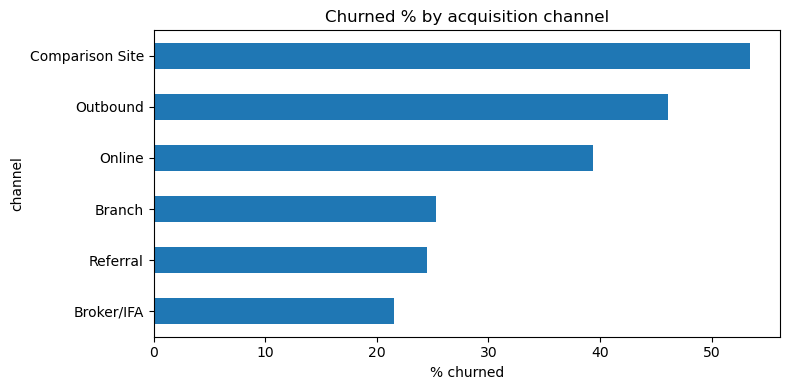

In [24]:
# Churn rate by channel
churn_by_channel = scv.groupby('channel')['churned'].mean().sort_values() * 100

plt.figure(figsize=(8, 4))
churn_by_channel.plot(kind='barh')
plt.title('Churned % by acquisition channel')
plt.xlabel('% churned')
plt.tight_layout(); plt.show()

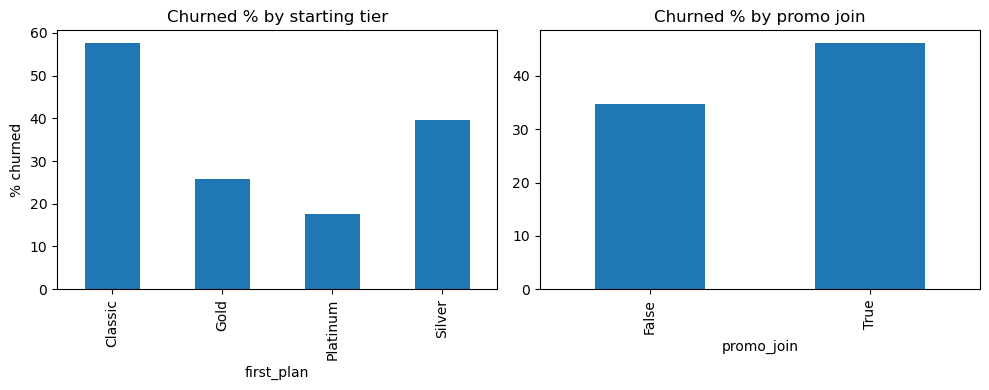

In [25]:
# Churn rate by starting tier and by promo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
(scv.groupby('first_plan')['churned'].mean() * 100).plot(kind='bar', ax=axes[0])
axes[0].set_title('Churned % by starting tier'); axes[0].set_ylabel('% churned')
(scv.groupby('promo_join')['churned'].mean() * 100).plot(kind='bar', ax=axes[1])
axes[1].set_title('Churned % by promo join')
plt.tight_layout(); plt.show()

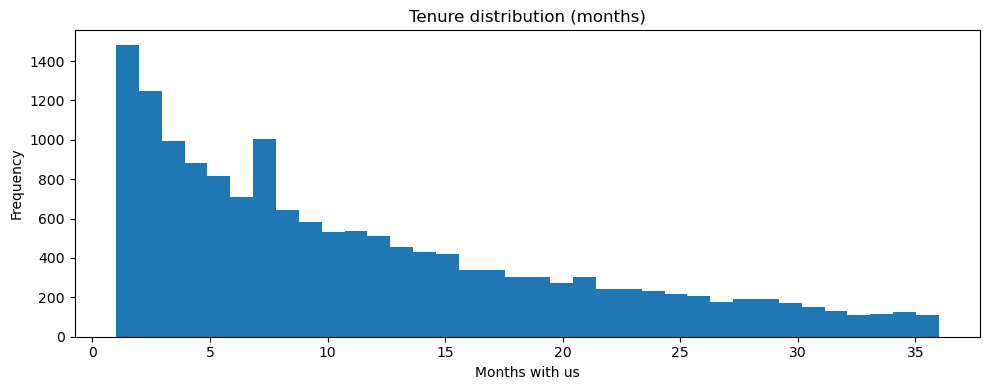

In [26]:
# How long do customers stay?
plt.figure(figsize=(10, 4))
scv['tenure_months'].plot(kind='hist', bins=36)
plt.title('Tenure distribution (months)')
plt.xlabel('Months with us')
plt.tight_layout(); plt.show()

# Most of the mass sits at small tenures. Only 109 customers ever reach 36 months, because that needs a Jan 2022 signup and no closure since.

### The two cohort figures, plus CSV exports for Tableau

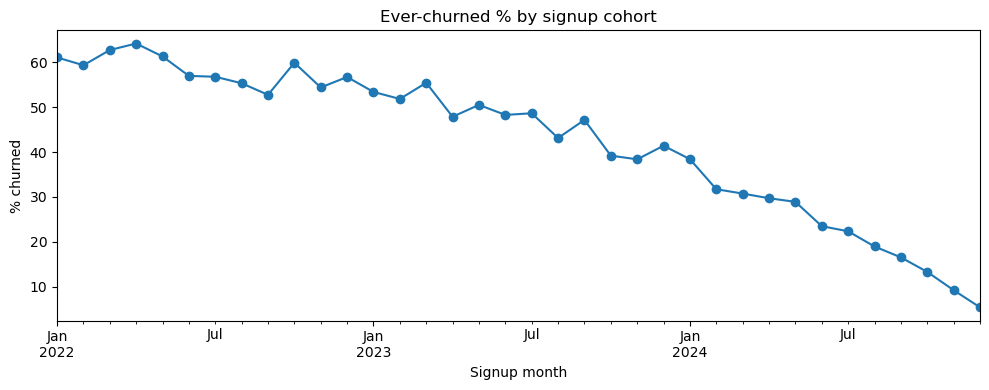

In [27]:
# Figure 1 - ever-churned % by signup cohort
cohort_churn = scv.groupby('signup_month')['churned'].mean() * 100

plt.figure(figsize=(10, 4))
cohort_churn.plot(marker='o')
plt.title('Ever-churned % by signup cohort')
plt.xlabel('Signup month'); plt.ylabel('% churned')
plt.tight_layout(); plt.show()
# the fall to the right is because late-2024 joiners simply haven't had time to churn yet, not better retention

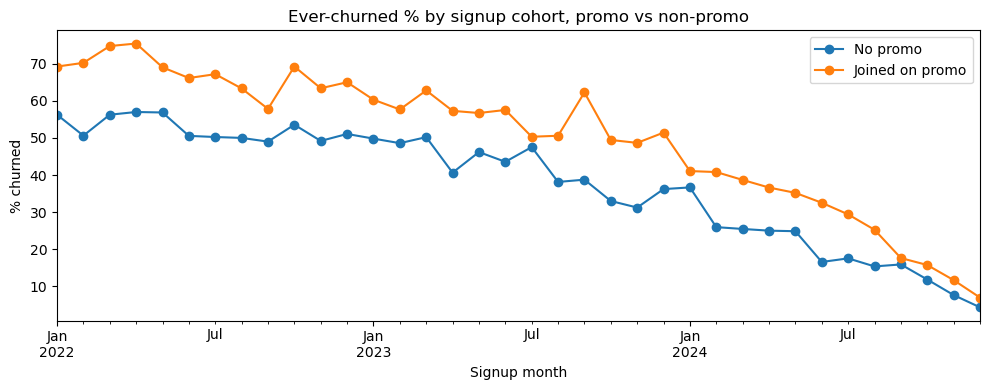

In [28]:
# Figure 2 - same cohorts, split promo vs non-promo
cohort_promo = (scv.groupby(['signup_month', 'promo_join'])['churned']
                   .mean().unstack() * 100)

plt.figure(figsize=(10, 4))
cohort_promo.plot(marker='o', ax=plt.gca())
plt.title('Ever-churned % by signup cohort, promo vs non-promo')
plt.xlabel('Signup month'); plt.ylabel('% churned')
plt.legend(['No promo', 'Joined on promo'])
plt.tight_layout(); plt.show()

In [29]:
# Exports for Tableau
cohort_churn.rename('pct_churned').to_csv('tableau_cohort_churn.csv')
cohort_promo.rename(columns={False: 'no_promo', True: 'promo'}).to_csv('tableau_cohort_churn_promo.csv')
summary.round(2).to_csv('tableau_channel_arpu.csv')
scv.drop(columns='plan_history').reset_index().to_csv('scv_export.csv', index=False)
print('written: tableau_cohort_churn.csv, tableau_cohort_churn_promo.csv,'
      ' tableau_channel_arpu.csv, scv_export.csv')

written: tableau_cohort_churn.csv, tableau_cohort_churn_promo.csv, tableau_channel_arpu.csv, scv_export.csv


---
# Insight findings

## Problem 1 - customers have not all been with us the same length of time

A channel that recruited heavily last autumn looks loyal, simply because its
customers have not had the chance to leave yet.

In [30]:
# exposure = how many months we have actually been able to watch each customer
final_month = df_acc['month'].max()
scv['months_observed'] = (final_month.ordinal
                          - scv['signup_month'].apply(lambda p: p.ordinal)) + 1

exposure = scv.groupby('channel').agg(
    customers       = ('churned', 'size'),
    churn_pct       = ('churned', lambda s: round(s.mean() * 100, 1)),
    avg_months_seen = ('months_observed', lambda s: round(s.mean(), 1)),
    joined_last_6m  = ('months_observed', lambda s: round((s <= 6).mean() * 100, 1)),
)
exposure.sort_values('churn_pct')

,customers,churn_pct,avg_months_seen,joined_last_6m
channel,,,,
Broker/IFA,979,21.6,16.6,20.9
Referral,1875,24.5,16.4,21.1
Branch,2481,25.3,16.5,22.0
Online,3851,39.4,16.2,21.2
Outbound,1962,46.1,16.0,23.2
Comparison Site,4584,53.4,16.2,22.4


In [31]:
# the same problem across the whole data
recent = (scv['months_observed'] <= 6).mean()
print(f'joined in the last 6 months: {recent:.1%}')
print('those customers cannot possibly show more than 6 months of tenure')

# this is exactly why the cohort chart above drops on the right hand side.

joined in the last 6 months: 21.9%
those customers cannot possibly show more than 6 months of tenure


## Fix for problem 1 - compare channels at the same age

Instead of 'what share ever left', ask 'what share are still here after N months'.
Test the idea on 2022 joiners only, where everyone has a full 36 months of history.

In [32]:
# like-for-like: 2022 joiners only, all observed for the full 36 months
lfl = scv[scv['signup_month'].apply(lambda p: p.year) == 2022]
print(f'2022 joiners: {len(lfl):,} of {len(scv):,}')

pd.DataFrame({
    'still_here_12m': lfl.groupby('channel')['tenure_months'].apply(
        lambda t: round((t > 12).mean() * 100, 1)),
    'still_here_24m': lfl.groupby('channel')['tenure_months'].apply(
        lambda t: round((t > 24).mean() * 100, 1)),
}).sort_values('still_here_24m')

2022 joiners: 3,982 of 15,732


,still_here_12m,still_here_24m
channel,,
Comparison Site,47.6,29.3
Outbound,57.5,39.0
Online,64.2,46.7
Branch,77.4,65.7
Referral,80.9,66.6
Broker/IFA,79.2,67.2


In [33]:
# that ranking is trustworthy, but it throws away two thirds of our customers.
# the survival curve keeps everyone, by counting each customer only for the months we can actually see them (CHART 1 below)

## Problem 2 - retention alone does not tell us where to spend

A channel can churn badly and still be worth buying if it is cheap enough.
A loyal channel can be a poor buy if it costs too much. So we need value per
customer set against cost per customer, which is CHART 2.

In [34]:
# what each channel costs us per customer
spend_by_channel = df_mark.groupby('channel')['spend_gbp'].sum()
cust_by_channel  = scv.groupby('channel').size()
cac = spend_by_channel / cust_by_channel

# against what each channel has actually paid us per customer so far
compare = pd.DataFrame({
    'customers'     : cust_by_channel,
    'cac'           : cac.round(2),
    'revenue_so_far': scv.groupby('channel')['total_revenue'].mean().round(2),
})
compare['ratio'] = (compare['revenue_so_far'] / compare['cac']).round(2)
compare.sort_values('ratio', ascending=False)

,customers,cac,revenue_so_far,ratio
channel,,,,
Referral,1875,59.74,215.52,3.61
Online,3851,69.94,127.44,1.82
Comparison Site,4584,39.79,63.71,1.60
Branch,2481,152.18,222.45,1.46
Broker/IFA,979,199.20,269.79,1.35
Outbound,1962,121.95,95.41,0.78


In [35]:
# 'revenue so far' undervalues recent joiners for the same reason as before.
# CHART 2 fixes it by projecting each channel over 36 months using its own survival curve, so every channel is valued over the same window.

---
# Presentation graphs

In [36]:
# MoneyCraft branding, so these match the slides.
# Fonts live in the fonts/ folder next to this notebook.
import glob
from matplotlib import font_manager

for ttf in glob.glob('fonts/*.ttf'):
    font_manager.fontManager.addfont(ttf)

HEAD = 'Poppins' if any('Poppins' in f for f in glob.glob('fonts/*.ttf')) else 'DejaVu Sans'
BODY = 'Lato'    if any('Lato'    in f for f in glob.glob('fonts/*.ttf')) else 'DejaVu Sans'

VIOLET = '#6C2BD9'   # neutral
MINT   = '#0E9F8C'   # positive / best
RED    = '#C0392B'   # negative / worst
INK    = '#211A3B'   # text
GREY   = '#B9AEDA'   # everything not being highlighted
CLOUD  = '#F6F4FC'   # background

plt.rcParams.update({
    'font.family'     : BODY,
    'text.color'      : INK,
    'axes.labelcolor' : INK,
    'xtick.color'     : INK,
    'ytick.color'     : INK,
    'axes.edgecolor'  : GREY,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.facecolor' : CLOUD,
    'axes.facecolor'   : CLOUD,
    'figure.dpi'       : 110,
})
print('using fonts:', HEAD, '/', BODY)

using fonts: Poppins / Lato


In [37]:
# Kaplan-Meier: share of a channel's customers still open after each month.
# Each customer counts only for the months we can actually see them, so recent joiners no longer drag everything down.
# Claude suggestion - verified online for retention modelling https://numiqo.com/tutorial/kaplan-meier-curve
def survival_curve(sub, horizon=36):
    tenure, churned = sub['tenure_months'].values, sub['churned'].values
    still_open, out = 1.0, []
    for t in range(1, horizon + 1):
        at_risk = (tenure >= t).sum()               # customers we can still observe
        left    = ((tenure == t) & churned).sum()   # of those, how many closed
        still_open *= 1 - left / max(at_risk, 1)
        out.append(still_open)
    return np.array(out)

In [38]:
# survival table for every channel
survival = pd.DataFrame({ch: survival_curve(sub) * 100
                         for ch, sub in scv.groupby('channel')},
                        index=range(1, 37))
survival.index.name = 'months_since_joining'
survival.round(1).tail()

,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
months_since_joining,,,,,,
32,59.2,65.7,22.4,36.2,28.1,59.7
33,59.2,65.7,22.1,35.5,26.9,58.3
34,58.6,63.7,21.3,35.0,26.9,58.3
35,56.9,63.7,20.7,33.5,25.7,58.3
36,56.9,63.7,20.7,33.5,25.7,58.3


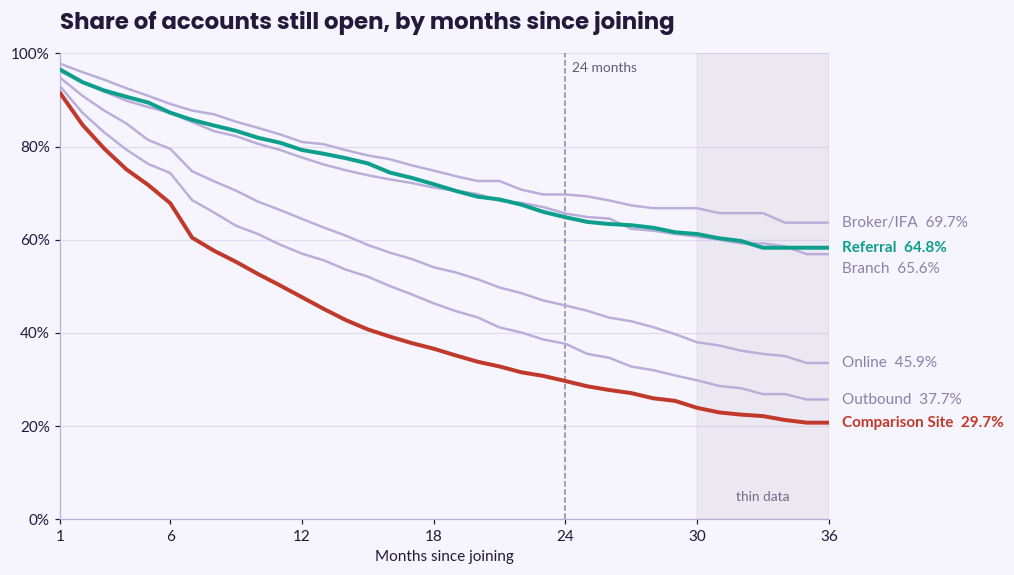

In [39]:
# CHART 1 - survival curves
# Colour carries the message: best channel mint, worst red, the rest grey.
HIGHLIGHT = {'Referral': MINT, 'Comparison Site': RED}

fig, ax = plt.subplots(figsize=(11, 5.5))

for ch in survival.columns:
    ax.plot(survival.index, survival[ch], color=HIGHLIGHT.get(ch, GREY),
            linewidth=2.6 if ch in HIGHLIGHT else 1.6,
            zorder=3 if ch in HIGHLIGHT else 2)

# Labels go at the right, showing the 24-month reading
ends = survival.iloc[-1].sort_values(ascending=False)
label_y, previous = {}, None
for ch, y in ends.items():
    if previous is not None and previous - y < 4.5:
        y = previous - 4.5
    label_y[ch] = previous = y

for ch, y in label_y.items():
    ax.text(36.6, y, '{}  {:.1f}%'.format(ch, survival.loc[24, ch]),
            va='center', ha='left', fontsize=10,
            color=HIGHLIGHT.get(ch, '#8A82A8'),
            fontweight='bold' if ch in HIGHLIGHT else 'normal')

# the point we actually read the chart at
ax.axvline(24, color=INK, linestyle='--', linewidth=1, alpha=0.5, zorder=1)
ax.text(24.3, 96, '24 months', fontsize=9, color=INK, alpha=0.7)

# past month 30 only a handful of customers per channel are left
ax.axvspan(30, 36, color=INK, alpha=0.05, zorder=0)
ax.text(33, 4, 'thin data', fontsize=9, color=INK, alpha=0.6, ha='center')

ax.set_xlim(1, 36); ax.set_ylim(0, 100)
ax.set_xticks([1, 6, 12, 18, 24, 30, 36])
ax.set_yticks(range(0, 101, 20))
ax.set_yticklabels([str(y) + '%' for y in range(0, 101, 20)])
ax.set_xlabel('Months since joining')
ax.grid(axis='y', color=GREY, alpha=0.35, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title('Share of accounts still open, by months since joining',
             fontfamily=HEAD, fontsize=15, fontweight='bold', loc='left', pad=16)

plt.subplots_adjust(right=0.76)
plt.show()

In [40]:
# how many customers are still being observed at each age?
# past month 30 there are very few left, so the far right of the chart is noisy
at_risk = pd.DataFrame({ch: [(sub['tenure_months'] >= t).sum() for t in range(1, 37)]
                        for ch, sub in scv.groupby('channel')},
                       index=range(1, 37))
at_risk.loc[[12, 24, 30, 36]]

,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
12,1213,510,1386,1559,696,930
24,485,192,395,495,212,348
30,222,79,153,206,89,163
36,35,10,12,23,11,18


In [41]:
# 36-month value per customer = survival x the fee typically paid at that age
df_acc['tenure_at_row'] = df_acc.groupby('customer_id').cumcount() + 1

rows = []
for ch, sub in scv.groupby('channel'):
    months = df_acc[(df_acc['acquisition_channel'] == ch)
                    & (df_acc['tenure_at_row'] <= 36)]
    fee_at_age = (months.groupby('tenure_at_row')['monthly_fee'].mean()
                        .reindex(range(1, 37)).ffill())
    rows.append({'channel'  : ch,
                 'customers': len(sub),
                 'cac'      : round(spend_by_channel[ch] / len(sub), 2),
                 'ltv_36m'  : round(float((survival_curve(sub) * fee_at_age.values).sum()), 2)})

bubble = pd.DataFrame(rows).set_index('channel')
bubble['net_value_per_customer'] = (bubble['ltv_36m'] - bubble['cac']).round(2)
bubble['ltv_to_cac'] = (bubble['ltv_36m'] / bubble['cac']).round(2)
bubble.sort_values('ltv_to_cac', ascending=False)

,customers,cac,ltv_36m,net_value_per_customer,ltv_to_cac
channel,,,,,
Referral,1875,59.74,461.41,401.67,7.72
Online,3851,69.94,270.10,200.16,3.86
Comparison Site,4584,39.79,131.27,91.48,3.30
Branch,2481,152.18,465.16,312.98,3.06
Broker/IFA,979,199.20,552.13,352.93,2.77
Outbound,1962,121.95,193.11,71.16,1.58


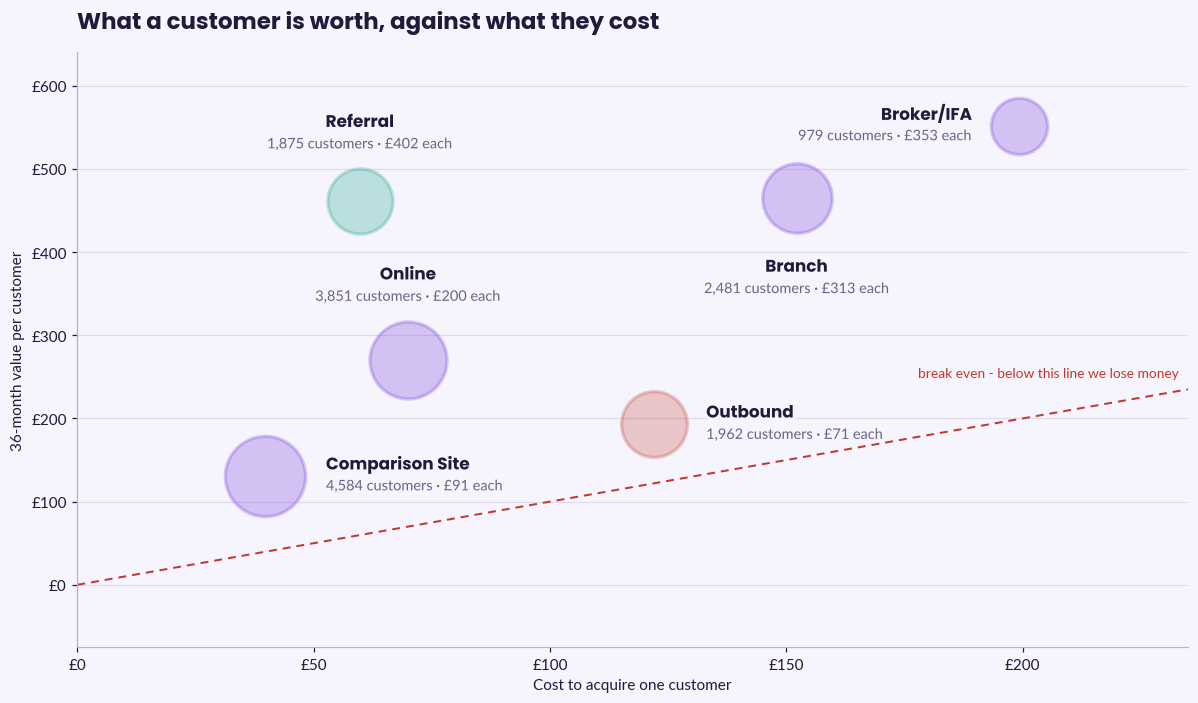

In [42]:
# CHART 2 - bubble chart
import matplotlib.patheffects as pe
HALO = [pe.withStroke(linewidth=3.5, foreground=CLOUD)]   # lets a label cross a line

# Colour by value: best mint, worst red, the rest violet.
FILL = {'Referral': MINT, 'Outbound': RED}

# Bubble AREA carries customer volume, on a compressed scale so the smallest
# channel stays visible
size = np.sqrt(bubble['customers'] / bubble['customers'].max()) * 2600 + 160

# which side of its bubble each label sits on
PLACE = {'Referral': 'above', 'Online': 'above', 'Outbound': 'right',
         'Comparison Site': 'right', 'Broker/IFA': 'left', 'Branch': 'below'}

fig, ax = plt.subplots(figsize=(11, 6.5))

for ch, r in bubble.iterrows():
    colour = FILL.get(ch, VIOLET)
    ax.scatter(r['cac'], r['ltv_36m'], s=size[ch], color=colour, alpha=0.25,
               edgecolors=colour, linewidth=2.2, zorder=3)

    # offset the label by the bubble's own radius, so it never sits on the mark
    radius = np.sqrt(size[ch] / np.pi)          # marker radius, in points
    side = PLACE[ch]
    if side in ('left', 'right'):
        dx = (radius + 10) * (1 if side == 'right' else -1)
        dy, ha = 0, ('left' if side == 'right' else 'right')
    else:
        dx, ha = 0, 'center'
        dy = (radius + 20) if side == 'above' else -(radius + 27)

    ax.annotate(ch, (r['cac'], r['ltv_36m']), textcoords='offset points',
                xytext=(dx, dy + 7), ha=ha, va='center', fontsize=11,
                fontweight='bold', fontfamily=HEAD, color=INK,
                zorder=5, path_effects=HALO)
    ax.annotate(u'{:,.0f} customers \u00b7 \u00a3{:.0f} each'.format(
                    r['customers'], r['net_value_per_customer']),
                (r['cac'], r['ltv_36m']), textcoords='offset points',
                xytext=(dx, dy - 7), ha=ha, va='center', fontsize=9.5,
                color='#6B6486', zorder=5, path_effects=HALO)

# break even: a customer is worth exactly what they cost
limit = 235
ax.plot([0, limit], [0, limit], color=RED, linestyle=(0, (4, 3)), linewidth=1.3, zorder=2)
ax.annotate('break even - below this line we lose money', xy=(limit, limit),
            xytext=(-6, 8), textcoords='offset points',
            ha='right', fontsize=9, color=RED)

ax.set_xlim(0, limit); ax.set_ylim(-75, 640)   # headroom for the below label
ax.set_yticks(range(0, 601, 100))
ax.set_xlabel('Cost to acquire one customer')
ax.set_ylabel('36-month value per customer')
ax.xaxis.set_major_formatter(lambda v, p: u'\u00a3{:,.0f}'.format(v))
ax.yaxis.set_major_formatter(lambda v, p: u'\u00a3{:,.0f}'.format(v))
ax.grid(axis='y', color=GREY, alpha=0.35, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title('What a customer is worth, against what they cost',
             fontfamily=HEAD, fontsize=15, fontweight='bold', loc='left', pad=16)

plt.tight_layout()
plt.show()

In [43]:
# exports for Tableau - long format, one row per channel-month
surv_long = (survival.round(1)
             .reset_index()
             .melt(id_vars='months_since_joining',
                   var_name='channel', value_name='still_open_pct'))
risk_long = (at_risk.rename_axis('months_since_joining')
             .reset_index()
             .melt(id_vars='months_since_joining',
                   var_name='channel', value_name='at_risk'))
surv_long = surv_long.merge(risk_long, on=['months_since_joining', 'channel'])

surv_long.to_csv('tableau_survival_curves.csv', index=False)
bubble.reset_index().to_csv('tableau_bubble_chart.csv', index=False)
print('written: tableau_survival_curves.csv ({} rows), tableau_bubble_chart.csv ({} rows)'
      .format(len(surv_long), len(bubble)))

written: tableau_survival_curves.csv (216 rows), tableau_bubble_chart.csv (6 rows)


---
# Group contributions

Everything above builds the single customer view and the two presentation
charts. Below is the rest of the group's work, as written. Cells that
duplicated work already done above have been dropped: the SCV build at the
top of RohanGraphs, and its bubble/survival export, which wrote the same two
CSVs as the Presentation graphs section.

## Promo vs non-promo closure hazard

In [44]:
# -- monthly closure hazard: of those still open at month t, who closed in it --

def hazard(sub):
    T, E = sub["tenure_months"].values, sub["churned"].values
    return np.array([((T == t) & E).sum() / max((T >= t).sum(), 1) * 100 for t in range(1, 25)]) # Returns the count of all churnes for each month divided by the count of all the accounts that haven't churned before that month. Then make it a percentage

hazard_promo = hazard(scv[scv["promo_join"]])
hazard_no_promo = hazard(scv[~scv["promo_join"]]) 

df_promo_churn = pd.DataFrame({
    'months_since_joining' : range(1,25),
    'no_promo_percentage_close'  : hazard_promo ,
    'promo_percentage_close': hazard_no_promo,
})


df_promo_churn.to_csv('promo_churn.csv', index=False, encoding='utf-8')

> **Check before using `promo_churn.csv`.** The two columns look swapped:
> `hazard_promo` (customers who joined on the promo) is written into the
> `no_promo_percentage_close` column, and `hazard_no_promo` into
> `promo_percentage_close`. The cell below shows which series carries the
> month-7 spike.

In [45]:
# quick check of which column holds which group
print('month 7 - promo customers    :', round(hazard_promo[6], 1), '%')
print('month 7 - non-promo customers:', round(hazard_no_promo[6], 1), '%')
print()
print('as written into the CSV:')
print(df_promo_churn.loc[6].to_string())

month 7 - promo customers    : 11.8 %
month 7 - non-promo customers: 2.5 %

as written into the CSV:
months_since_joining          7.000000
no_promo_percentage_close    11.756453
promo_percentage_close        2.485913


## Cost, value and Tableau exports

These build on the `scv` created at the top of this notebook, then reshape
it into the schema each Tableau sheet needs. `df_clos` is loaded first
because the closure-reason export uses it.

In [46]:
df_clos = pd.read_csv('moneycraft_closure_reasons.csv')
df_clos['close_month'] = pd.PeriodIndex(df_clos['close_month'], freq='M')
df_clos.head()

,customer_id,close_month,reason_code
0,10755,2024-05,Switched provider
1,7582,2025-01,Unhappy with perks
2,2162,2024-11,Fees too high
3,3016,2023-02,Switched provider
4,564,2022-07,Poor service


In [47]:
first = df_acc.sort_values('month').drop_duplicates('customer_id')
joiners = first.groupby(['month', 'acquisition_channel']).size()

spend = df_mark.set_index(['month', 'channel'])['spend_gbp']

cac = (spend / joiners).round(2).unstack()
cac.tail()

channel,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
month,,,,,,
2024-08,157.33,209.86,43.32,71.28,118.40,58.66
2024-09,139.43,216.32,42.31,71.39,117.58,61.32
2024-10,156.00,207.53,41.88,71.73,122.77,54.82
2024-11,147.09,199.37,39.31,74.88,121.65,58.73
2024-12,153.36,197.85,39.55,68.74,128.36,62.77


In [48]:
df_LTV = df_acc.copy().groupby('customer_id')['monthly_fee'].sum().reset_index().sort_values('customer_id')
df_LTV.rename(columns={'monthly_fee': 'lifetime_value'}, inplace=True)
df_LTV.head()

,customer_id,lifetime_value
0,1,0
1,2,595
2,3,848
3,4,330
4,5,33


In [49]:
# 1. tenure per customer — needs the monthly panel, scv can't provide it
acc = df_acc.sort_values(['customer_id', 'month']).copy()
acc['tenure'] = acc.groupby('customer_id').cumcount()

# 2. eligibility comes straight from scv
eligible = scv.index[scv['signup_month'] <= '2024-01']
first12 = acc[acc['customer_id'].isin(eligible) & (acc['tenure'] < 12)]

# 3. first-12-month value, joined back onto scv
scv['value_12m'] = first12.groupby('customer_id')['monthly_fee'].sum()

# 4. CAC per channel
joiners = scv['channel'].value_counts()
cac = df_mark.groupby('channel')['spend_gbp'].sum() / joiners
scv['CAC'] = scv['channel'].map(cac.round(2))

# 5. summary table
out = pd.DataFrame({'value_12m': scv.groupby('channel')['value_12m'].mean().round(2),
                    'CAC': cac.round(2)})
out['ratio'] = (out.value_12m / out.CAC).round(2)
out = out.sort_values('ratio', ascending=False)

# 6. Tableau export — eligible customers only, old column names kept
df_tableau = scv[scv['value_12m'].notna()].copy()
df_tableau['cohort'] = df_tableau['signup_month'].dt.year.astype(str)
df_tableau['signup_month'] = df_tableau['signup_month'].dt.to_timestamp()
df_tableau['value_12m'] = df_tableau['value_12m'].astype(int)
df_tableau = df_tableau[['signup_month', 'cohort', 'channel', 'region', 'age_band',
                         'first_plan', 'promo_join', 'tenure_months', 'churned',
                         'value_12m', 'CAC']].reset_index()
df_tableau = df_tableau.rename(columns={'signup_month': 'join_month',
                                        'promo_join': 'promo',
                                        'first_plan': 'tier_at_join'})
df_tableau.to_csv('tableau_customer_value.csv', index=False)

In [50]:
# 1. churners come straight from scv
churners = scv[scv['churned']]

# 2. attach the reason — inner join keeps only churners who have one
df_reasons = churners.join(df_clos.set_index('customer_id')['reason_code'], how='inner')
df_reasons['promo_group'] = df_reasons['promo_join'].map({True: 'Joined on promo', False: 'No promo'})

# 3. tidy to the columns Tableau needs, with the old names
df_reasons = (df_reasons[['promo_join', 'channel', 'region', 'age_band', 'first_plan',
                          'tenure_months', 'reason_code', 'promo_group']]
              .rename(columns={'promo_join': 'promo',
                               'tenure_months': 'tenure',
                               'first_plan': 'tier_at_join'})
              .reset_index())
df_reasons.to_csv('tableau_closure_reasons.csv', index=False)

## Return per pound by channel

This figure is self-contained: it builds its own small customer table from
the raw files rather than reusing `scv`. That means `scv` is redefined from
here on, so it is placed last. Restart and run from the top if you go back
to any earlier cell.

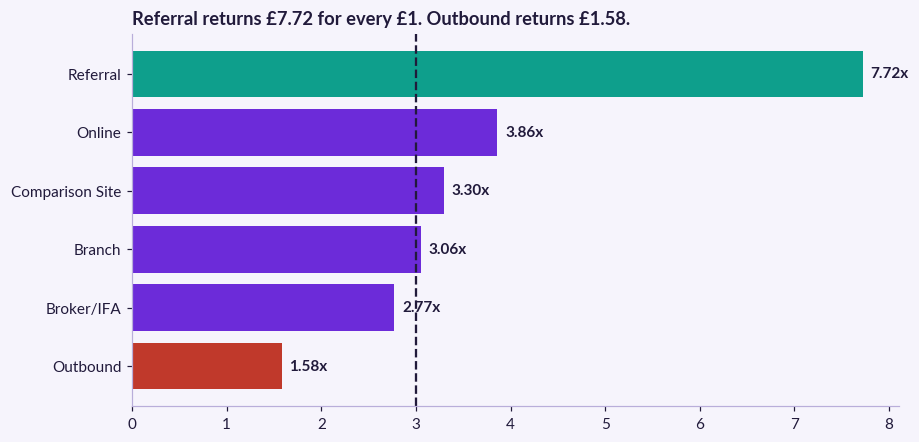

In [51]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

acc = pd.read_csv("moneycraft_accounts.csv")
acc["month"] = pd.PeriodIndex(acc["month"], freq="M")
acc = acc.sort_values(["customer_id", "month"])

# one row per customer; churn = their rows stop before Dec 2024
g = acc.groupby("customer_id")
scv = pd.DataFrame({"tenure": g["month"].count(),
                    "channel": g["acquisition_channel"].first(),
                    "signup":  g["month"].min()})
scv["churned"] = g["month"].max() < acc["month"].max()

# 211 customers have a closure logged for Jan 2025 -> churned, not survivors
closed = pd.read_csv("moneycraft_closure_reasons.csv")
scv.loc[scv.index.isin(closed.customer_id) & ~scv.churned, "churned"] = True

# CAC = 3-year spend / customers won
spend = pd.read_csv("moneycraft_marketing_spend.csv").groupby("channel").spend_gbp.sum()
cac = spend / scv.groupby("channel").size()

# Kaplan-Meier: P(still open at month t), recent joiners censored
def km(sub, H=36):
    T, E, s, out = sub["tenure"].values, sub["churned"].values, 1.0, []
    for t in range(1, H + 1):
        s *= 1 - ((T == t) & E).sum() / max((T >= t).sum(), 1)
        out.append(s)
    return np.array(out)
S = {c: km(sub) for c, sub in scv.groupby("channel")}

# fee by tenure month (rises as waivers end), then LTV = sum of S(t) x fee(t)
acc["ten"] = acc.groupby("customer_id").cumcount() + 1
acc["ch"]  = acc["customer_id"].map(scv["channel"])
fee = acc[acc.ten <= 36].pivot_table(index="ten", columns="ch",
                                     values="monthly_fee", aggfunc="mean")
ltv   = pd.Series({c: (S[c] * fee[c].values).sum() for c in S})
ratio = (ltv / cac).sort_values()

# plot
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(ratio.index, ratio.values,
        color=["#C0392B" if v < 2 else "#0E9F8C" if v >= 5 else "#6C2BD9"
               for v in ratio])
ax.axvline(3, ls="--", color="#211A3B")           # healthy-channel bar
for c, v in ratio.items():
    ax.text(v + .08, c, f"{v:.2f}x", va="center", fontweight="bold")
ax.set_title("Referral returns £7.72 for every £1. Outbound returns £1.58.",
             loc="left", fontweight="bold")
plt.show()

In [52]:
first = df_acc.sort_values('month').drop_duplicates('customer_id')
classic_promo = first[(first.account_tier == 'Classic') & (first.joined_on_promo)]

classic_promo.head(20)

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo,tenure_at_row
200,201,2022-01,Comparison Site,South East,35-44,Classic,0,True,1
217,218,2022-01,Online,London,55-64,Classic,0,True,1
191,192,2022-01,Outbound,South East,55-64,Classic,0,True,1
162,163,2022-01,Online,South East,35-44,Classic,0,True,1
165,166,2022-01,Online,London,55-64,Classic,0,True,1
24,25,2022-01,Branch,North,45-54,Classic,0,True,1
166,167,2022-01,Comparison Site,Scotland,18-24,Classic,0,True,1
177,178,2022-01,Comparison Site,South East,35-44,Classic,0,True,1
12,13,2022-01,Comparison Site,London,25-34,Classic,0,True,1
275,276,2022-01,Outbound,North,35-44,Classic,0,True,1


In [53]:
df_acc.loc[df_acc['account_tier'] == 'Classic', 'monthly_fee'].sum()

np.int64(0)